<a href="https://colab.research.google.com/github/keerthisl/Oceanographic-Analysis-Projects/blob/Master/Indian_Ocean_Region_SST_Analysis_v2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Indian Ocean Region SST Analysis v2.0
# Keerthi A.
# Date: February 26, 2025

# This notebook analyzes Sea Surface Temperature (SST) data for the Indian Ocean Region.
# It includes temporal trends, spatial patterns, seasonal variations, and anomaly detection.
# Version 2.0 adds support for both low-resolution historical data and high-resolution recent data.
# You can toggle between dataset types by changing the DATASET_TYPE variable
# (set to "ersst" by default, can be changed to "highres" for higher resolution data).

In [2]:
# ============================================================
# SECTION 1: Environment Setup and Libraries (v2.0)
# ============================================================
# Purpose: Install and import all required libraries for the analysis

# Install required packages
!pip install xarray netCDF4 matplotlib cartopy cmocean

# Import libraries
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean  # Ocean-specific colormaps
from google.colab import drive
import warnings
from datetime import datetime, timedelta
from scipy import stats
import os
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Mount Google Drive to access your data (if needed)
try:
    from google.colab import auth
    auth.authenticate_user()
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Note: Google Drive mounting failed or not needed: {e}")

print("Environment setup complete!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.2 MB/s eta 0:00:00
Mounted at /content/drive
Google Drive mounted successfully!
Environment setup complete!


In [3]:
# ============================================================
# SECTION 2: Data Access Module (v2.0)
# ============================================================
# Purpose: Provide modular access to different ocean temperature datasets

def load_ocean_dataset(dataset_type="ersst", region="indian_ocean"):
    """
    Load ocean temperature dataset with options for different sources and regions

    Parameters:
    -----------
    dataset_type : str
        Type of dataset to load: "ersst" (low-res, long historical) or "highres" (high-res, recent)
    region : str
        Region to extract: "indian_ocean", "global", or "custom"

    Returns:
    --------
    xarray.Dataset: The loaded dataset
    str: Name of the main temperature variable
    """
    # Define region bounds
    regions = {
        "indian_ocean": {"lat": (-30, 30), "lon": (40, 120)},
        "global": {"lat": (-90, 90), "lon": (0, 360)},
    }

    # Get the selected region bounds
    selected_region = regions.get(region, regions["indian_ocean"])

    if dataset_type.lower() == "ersst":
        # Load ERSST data (low resolution, long historical record)
        try:
            print("Loading ERSST data...")
            url = 'https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc'
            sst_global = xr.open_dataset(url)

            # Find indices for the selected region
            lat = sst_global['lat'].values
            lon = sst_global['lon'].values

            lat_indices = np.where((lat >= selected_region["lat"][0]) &
                                  (lat <= selected_region["lat"][1]))[0]
            lon_indices = np.where((lon >= selected_region["lon"][0]) &
                                  (lon <= selected_region["lon"][1]))[0]

            # Select the region using these indices
            print(f"Extracting {region} region data...")
            sst_data = sst_global.isel(lat=lat_indices, lon=lon_indices)

            return sst_data, 'sst'

        except Exception as e:
            print(f"Error loading ERSST dataset: {e}")
            return None, None

    elif dataset_type.lower() == "highres":
        # Load high-resolution data (more recent, better detail)
        try:
            # Get a recent date (the dataset has about 1-week delay)
            today = datetime.now()
            date_to_use = today - timedelta(days=10)
            date_str = date_to_use.strftime("%Y%m%d")

            print(f"Accessing high-resolution SST data...")

            # Try one of several high-res sources
            urls = [
                "https://podaac-opendap.jpl.nasa.gov/opendap/allData/ghrsst/data/GDS2/L4/GLOB/CMC/CMC0.1deg/v3/2023/001/20230101120000-CMC-L4_GHRSST-SSTfnd-CMC0.1deg-GLOB-v03.0-fv03.0.nc",
                "https://thredds.jpl.nasa.gov/thredds/dodsC/sea_surface_temperature/MUR-JPL-L4-GLOB-v4.1/2023/001/20230101090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc"
            ]

            sst_data = None
            for url in urls:
                try:
                    sst_data = xr.open_dataset(url)
                    print(f"Successfully loaded dataset from {url}")
                    break
                except:
                    continue

            if sst_data is None:
                raise Exception("Could not access any high-resolution datasets")

            # Find the temperature variable name
            temp_var_names = ['analysed_sst', 'sea_surface_temperature', 'sst', 'temperature']
            sst_var_name = None

            for var in sst_data.data_vars:
                if var.lower() in temp_var_names or 'sst' in var.lower() or 'temp' in var.lower():
                    sst_var_name = var
                    break

            if sst_var_name is None and len(list(sst_data.data_vars)) > 0:
                sst_var_name = list(sst_data.data_vars)[0]

            # Extract the region
            lat_name = 'lat' if 'lat' in sst_data.dims else 'latitude'
            lon_name = 'lon' if 'lon' in sst_data.dims else 'longitude'

            # Handle longitude range differences
            lon_min, lon_max = selected_region["lon"]
            if sst_data[lon_name].max() > 180 and lon_min < 0:
                # Convert from -180:180 to 0:360 if needed
                lon_min = lon_min % 360
                lon_max = lon_max % 360

            region_data = sst_data.sel({
                lat_name: slice(selected_region["lat"][0], selected_region["lat"][1]),
                lon_name: slice(lon_min, lon_max)
            })

            return region_data, sst_var_name

        except Exception as e:
            print(f"Error loading high-resolution dataset: {e}")
            print("Falling back to ERSST data...")
            # Recursive call to fall back to ERSST data
            return load_ocean_dataset("ersst", region)

    else:
        print(f"Unknown dataset type: {dataset_type}")
        print("Falling back to ERSST data...")
        return load_ocean_dataset("ersst", region)

In [4]:
# ============================================================
# SECTION 3: Data Loading and Exploration (v2.0)
# ============================================================
# Purpose: Load the NetCDF file and explore its structure

# Choose your dataset type: "ersst" (1854-present, low-res) or "highres" (recent data, high-res)
# DATASET_TYPE = "highres"  # Uncomment to use high-resolution data
DATASET_TYPE = "ersst"     # Default to ERSST data

# Load the dataset using our modular function
sst_data, sst_var_name = load_ocean_dataset(dataset_type=DATASET_TYPE, region="indian_ocean")

if sst_data is not None and sst_var_name is not None:
    print("Successfully loaded the dataset!")

    # Access the main SST variable
    sst = sst_data[sst_var_name]

    # Display dataset information
    print("\nDataset Overview:")
    print(sst_data)

    # Identify coordinate names
    lat_var = 'lat' if 'lat' in sst_data.dims else 'latitude'
    lon_var = 'lon' if 'lon' in sst_data.dims else 'longitude'

    # Print dimensions
    print("\nDimensions:")
    for dim_name, dim_size in sst_data.dims.items():
        print(f"  {dim_name}: {dim_size}")

    # Print variables
    print("\nVariables:")
    for var_name, var_data in sst_data.variables.items():
        print(f"  {var_name}: {var_data.dims}")
        if hasattr(var_data, 'units'):
            print(f"    Units: {var_data.units}")

    # Print time range if available
    if 'time' in sst_data.dims:
        time_values = sst_data['time'].values
        print(f"\nTime Range: {pd.to_datetime(time_values[0])} to {pd.to_datetime(time_values[-1])}")
        print(f"Number of time steps: {len(time_values)}")

    # Print spatial extent
    print(f"\nSpatial Extent:")
    print(f"  Latitude: {sst_data[lat_var].values.min()} to {sst_data[lat_var].values.max()}")
    print(f"  Longitude: {sst_data[lon_var].values.min()} to {sst_data[lon_var].values.max()}")
else:
    print("Failed to load dataset.")
    raise Exception("Dataset loading failed. Cannot continue analysis.")

Loading ERSST data...
Extracting indian_ocean region data...
Successfully loaded the dataset!

Dataset Overview:
<xarray.Dataset> Size: 10MB
Dimensions:    (lat: 31, lon: 41, time: 2054, nbnds: 2)
Coordinates:
  * lat        (lat) float32 124B 30.0 28.0 26.0 24.0 ... -26.0 -28.0 -30.0
  * lon        (lon) float32 164B 40.0 42.0 44.0 46.0 ... 116.0 118.0 120.0
  * time       (time) datetime64[ns] 16kB 1854-01-01 1854-02-01 ... 2025-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 10MB ...
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
   


Performing temporal analysis...


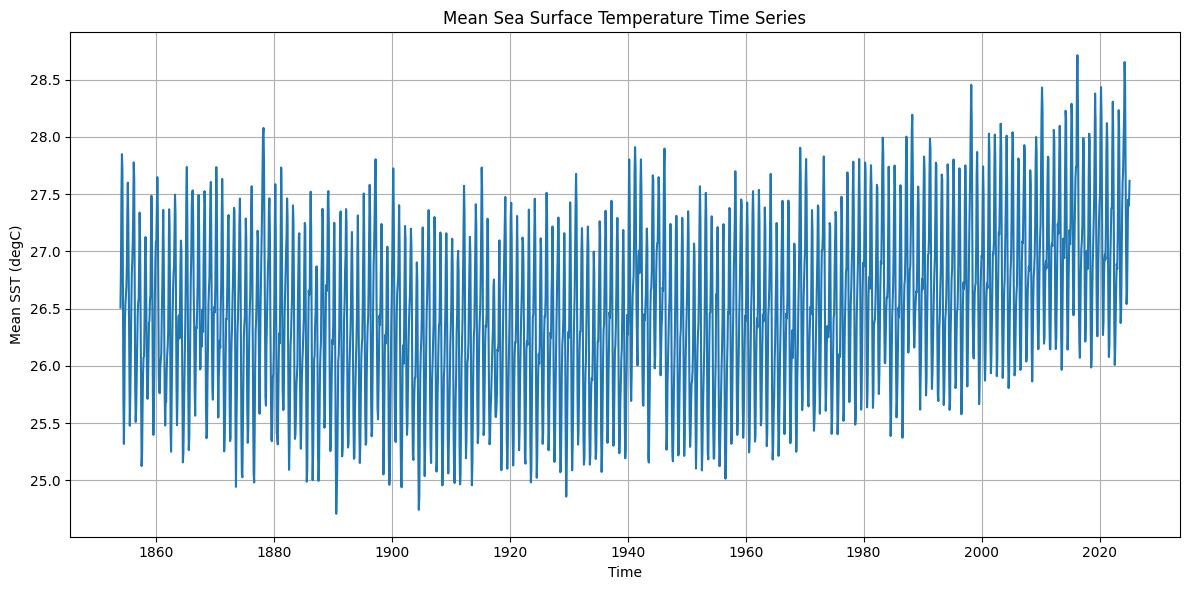


Trend Analysis:
  Slope: 0.0432 °C/decade (p-value: 0.0000)
  R-squared: 0.0805
  Statistical significance: Significant at 95% confidence level


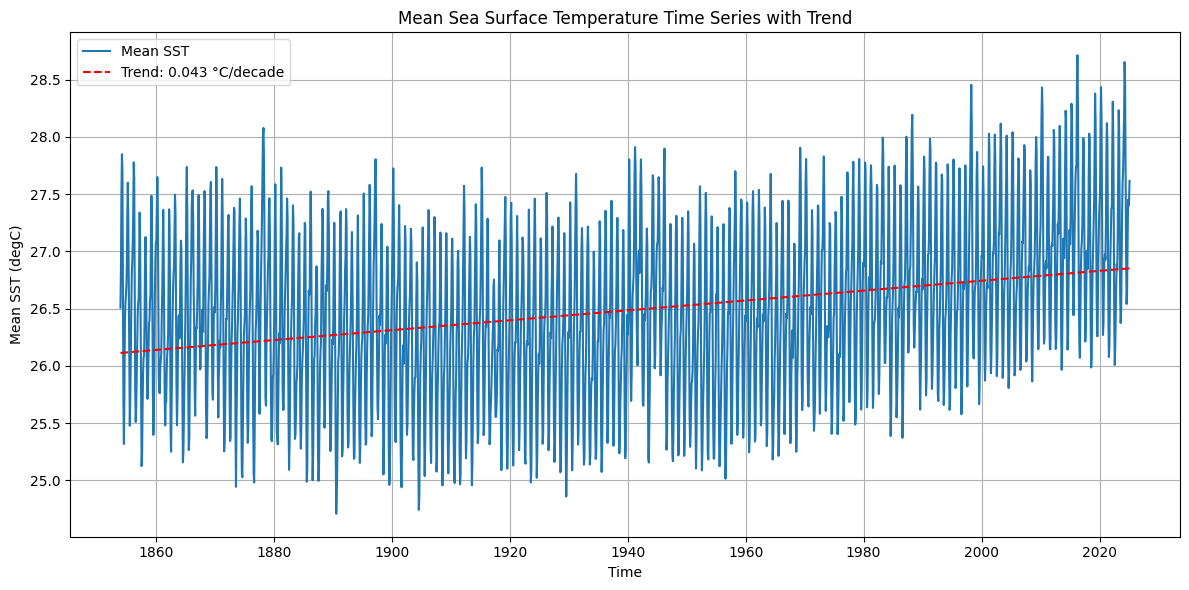

In [5]:
# ============================================================
# SECTION 4: Temporal Analysis (v2.0)
# ============================================================
# Purpose: Analyze how SST varies over time

if 'sst_data' in locals() and sst_data is not None and 'sst_var_name' in locals() and sst_var_name:
    # Calculate spatial mean for each time step
    print("\nPerforming temporal analysis...")
    spatial_mean = sst.mean(dim=[lat_var, lon_var], skipna=True)

    # Convert to a pandas Series for easier plotting
    if 'time' in spatial_mean.dims:
        time_series = spatial_mean.to_series()

        # Plot the time series
        plt.figure(figsize=(12, 6))
        plt.plot(time_series.index, time_series.values)
        plt.title('Mean Sea Surface Temperature Time Series')
        plt.xlabel('Time')
        plt.ylabel(f'Mean SST ({sst.units if hasattr(sst, "units") else "°C"})')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Calculate and print trend
        if len(time_series) > 1:
            x = np.arange(len(time_series))
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, time_series.values)

            # Calculate trend per decade (assuming monthly data)
            trend_per_decade = slope * 120  # 120 months in a decade

            print(f"\nTrend Analysis:")
            print(f"  Slope: {trend_per_decade:.4f} °C/decade (p-value: {p_value:.4f})")
            print(f"  R-squared: {r_value**2:.4f}")
            print(f"  Statistical significance: {'Significant' if p_value < 0.05 else 'Not significant'} at 95% confidence level")

            # Overlay trend line on the plot
            plt.figure(figsize=(12, 6))
            plt.plot(time_series.index, time_series.values, label='Mean SST')
            plt.plot(time_series.index, intercept + slope * x, 'r--',
                     label=f'Trend: {trend_per_decade:.3f} °C/decade')
            plt.title('Mean Sea Surface Temperature Time Series with Trend')
            plt.xlabel('Time')
            plt.ylabel(f'Mean SST ({sst.units if hasattr(sst, "units") else "°C"})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
    else:
        print("Cannot perform temporal analysis: No time dimension found in data")


Creating spatial visualization...
Mean SST shape: (31, 41)
Mean SST contains NaN values: True


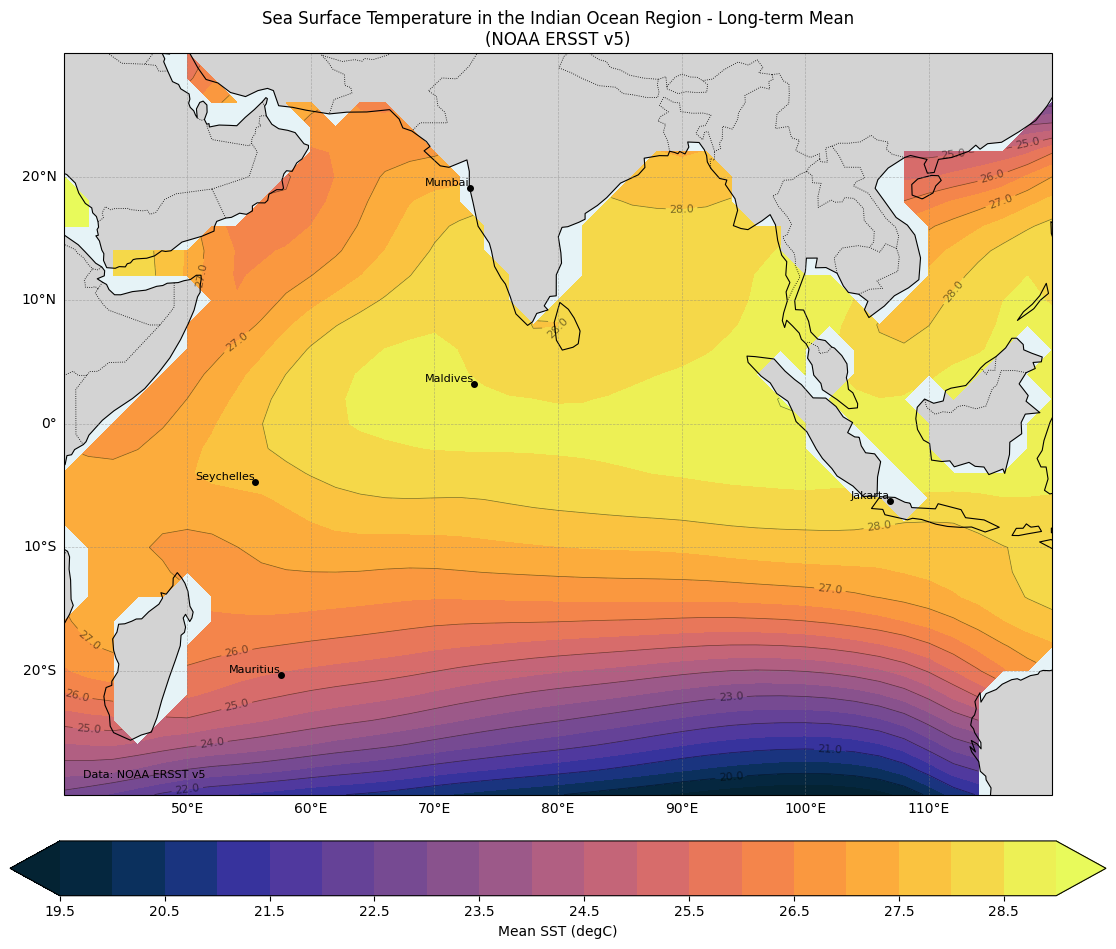

In [6]:
# ============================================================
# SECTION 5: Spatial Visualization (v2.0)
# ============================================================
# Purpose: Create maps showing the spatial patterns of SST

if 'sst_data' in locals() and sst_data is not None and 'sst_var_name' in locals() and sst_var_name:
    print("\nCreating spatial visualization...")

    # Calculate temporal mean
    if 'time' in sst.dims:
        mean_sst = sst.mean(dim='time', skipna=True)
        title_suffix = 'Long-term Mean'
    else:
        # For datasets without time dimension, just use the data as is
        mean_sst = sst
        title_suffix = 'Current Conditions'

    print(f"Mean SST shape: {mean_sst.shape}")
    print(f"Mean SST contains NaN values: {np.isnan(mean_sst).any().values}")

    # Create a map of the mean SST
    plt.figure(figsize=(14, 10))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=80))

    # Add more detailed features
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # Plot data - with different approaches depending on resolution
    if DATASET_TYPE.lower() == "ersst":
        # For low-res data, use contouring for smoother visuals
        lon, lat = np.meshgrid(mean_sst[lon_var].values, mean_sst[lat_var].values)

        # Use contourf for smoother appearance
        levels = 20  # More levels for smoother gradients
        im = ax.contourf(lon, lat, mean_sst.values,
                        levels=levels,
                        transform=ccrs.PlateCarree(),
                        cmap=cmocean.cm.thermal,
                        extend='both')  # Extend colorbar for out-of-range values

        # Add contour lines for more definition
        contour = ax.contour(lon, lat, mean_sst.values,
                            levels=10,
                            colors='black',
                            linewidths=0.5,
                            alpha=0.5,
                            transform=ccrs.PlateCarree())
        plt.clabel(contour, inline=True, fontsize=8, fmt='%.1f')
    else:
        # For high-res data, direct plotting works well
        im = mean_sst.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap=cmocean.cm.thermal,
                         add_colorbar=False)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(f'Mean SST ({sst.units if hasattr(sst, "units") else "°C"})')

    # Add key locations for reference
    key_locations = {
        'Mumbai': (72.8777, 19.0760),
        'Jakarta': (106.8456, -6.2088),
        'Mauritius': (57.5522, -20.3484),
        'Perth': (115.8613, -31.9505),
        'Maldives': (73.2207, 3.2028),
        'Seychelles': (55.4920, -4.6796)
    }

    for name, (lon, lat) in key_locations.items():
        # Only include points within our map bounds
        if 40 <= lon <= 120 and -30 <= lat <= 30:
            ax.plot(lon, lat, 'ko', markersize=4, transform=ccrs.PlateCarree())
            ax.text(lon, lat, name, fontsize=8, transform=ccrs.PlateCarree(),
                   horizontalalignment='right', verticalalignment='bottom')

    # Set title
    if DATASET_TYPE.lower() == "ersst":
        data_source = "NOAA ERSST v5"
    else:
        data_source = "High-Resolution SST"

    plt.title(f'Sea Surface Temperature in the Indian Ocean Region - {title_suffix}\n({data_source})')

    # Add text for data source
    plt.text(0.02, 0.02, f'Data: {data_source}', transform=ax.transAxes,
             fontsize=8, verticalalignment='bottom')

    # Set extent to focus on the Indian Ocean
    ax.set_extent([40, 120, -30, 30], crs=ccrs.PlateCarree())

    # Show the plot
    plt.tight_layout()
    plt.show()



Performing seasonal analysis...


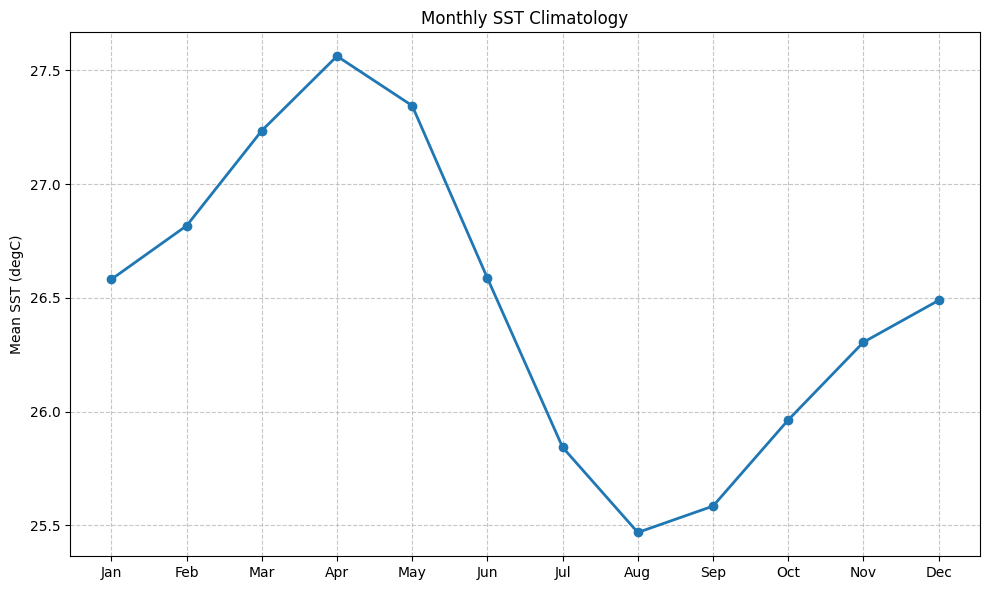

Error in seasonal analysis: list indices must be integers or slices, not DataArray


In [7]:
# ============================================================
# SECTION 6: Seasonal Analysis (v2.0)
# ============================================================
# Purpose: Analyze seasonal patterns in SST

if 'sst_data' in locals() and sst_data is not None and 'sst_var_name' in locals() and sst_var_name:
    # Only perform seasonal analysis if we have time dimension with multiple years
    if 'time' in sst.dims and len(sst['time']) >= 12:
        print("\nPerforming seasonal analysis...")

        try:
            # Group by month and calculate the mean
            if hasattr(sst, 'groupby'):
                monthly_mean = sst.groupby('time.month').mean(dim='time')

                # Plot the monthly means
                plt.figure(figsize=(10, 6))

                # Calculate spatial mean for each month
                spatial_monthly_mean = monthly_mean.mean(dim=[lat_var, lon_var], skipna=True)

                # Plot monthly climatology
                months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
                plt.plot(range(1, 13), spatial_monthly_mean.values, 'o-', linewidth=2)
                plt.xticks(range(1, 13), months)
                plt.grid(True, linestyle='--', alpha=0.7)
                plt.title('Monthly SST Climatology')
                plt.ylabel(f'Mean SST ({sst.units if hasattr(sst, "units") else "°C"})')
                plt.tight_layout()
                plt.show()

                # Calculate range of seasonal variation
                if len(spatial_monthly_mean) == 12:  # Make sure we have all months
                    seasonal_range = spatial_monthly_mean.max() - spatial_monthly_mean.min()
                    warmest_month = months[spatial_monthly_mean.argmax()]
                    coldest_month = months[spatial_monthly_mean.argmin()]

                    print(f"\nSeasonal Analysis:")
                    print(f"  Warmest month: {warmest_month}")
                    print(f"  Coldest month: {coldest_month}")
                    print(f"  Seasonal range: {seasonal_range:.2f}{' ' + sst.units if hasattr(sst, 'units') else ' °C'}")

                    # Create a heatmap of monthly SST patterns
                    plt.figure(figsize=(12, 6))
                    ax = plt.axes(projection=ccrs.PlateCarree())
                    ax.coastlines()
                    ax.set_extent([40, 120, -30, 30], crs=ccrs.PlateCarree())

                    # Choose 4 representative months (January, April, July, October)
                    representative_months = [1, 4, 7, 10]

                    fig, axes = plt.subplots(2, 2, figsize=(15, 12),
                                           subplot_kw={'projection': ccrs.PlateCarree()})
                    axes = axes.flatten()

                    for i, month in enumerate(representative_months):
                        ax = axes[i]
                        month_data = monthly_mean.sel(month=month)

                        # Add map features
                        ax.add_feature(cfeature.LAND, facecolor='lightgray')
                        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
                        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)

                        # Plot the data
                        lon, lat = np.meshgrid(month_data[lon_var].values, month_data[lat_var].values)
                        cs = ax.contourf(lon, lat, month_data.values,
                                       transform=ccrs.PlateCarree(),
                                       cmap=cmocean.cm.thermal,
                                       levels=20)

                        # Set title and add gridlines
                        ax.set_title(f'{months[month-1]} Sea Surface Temperature')
                        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
                        gl.top_labels = False
                        gl.right_labels = False

                        # Set extent
                        ax.set_extent([40, 120, -30, 30], crs=ccrs.PlateCarree())

                    # Add a colorbar
                    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
                    cbar = fig.colorbar(cs, cax=cbar_ax)
                    cbar.set_label(f'SST ({sst.units if hasattr(sst, "units") else "°C"})')

                    plt.suptitle('Seasonal Variability of Sea Surface Temperature', fontsize=16)
                    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
                    plt.show()
        except Exception as e:
            print(f"Error in seasonal analysis: {e}")
    else:
        print("\nSkipping seasonal analysis: Insufficient time data")


Performing anomaly analysis...


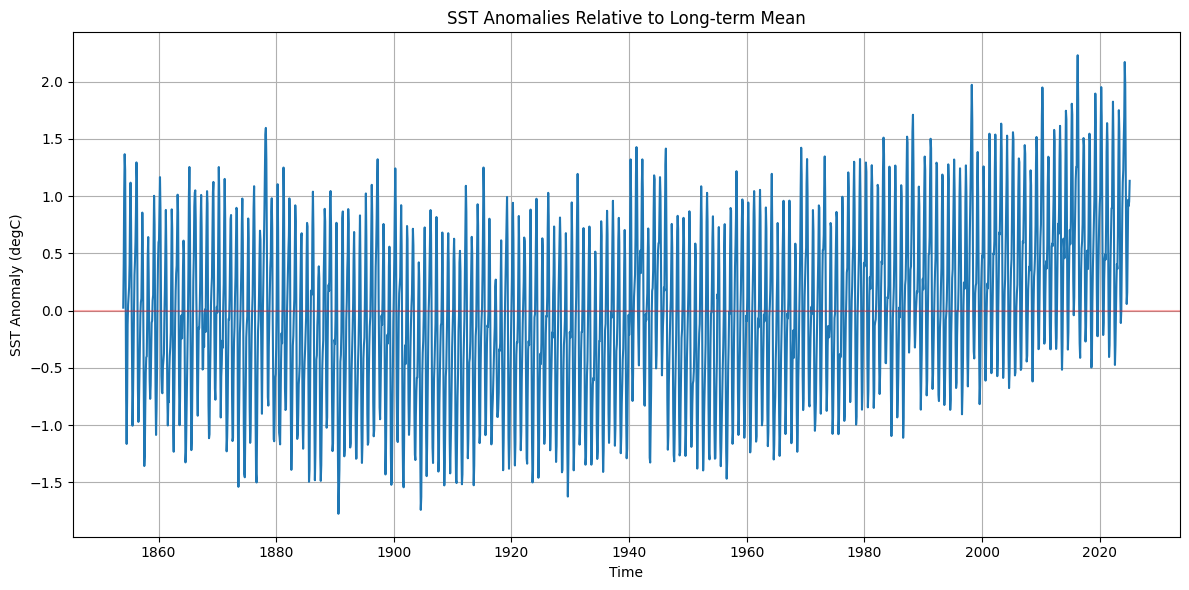


Anomaly Trend Analysis:
  Slope: 0.0432 °C/decade (p-value: 0.0000)
  R-squared: 0.0805

Extreme Anomalies (> 2 standard deviations):
  Positive anomalies: 42 occurrences
  Negative anomalies: 12 occurrences
  Largest positive anomaly: 2.23 degC on 2016-04-01 00:00:00
  Largest negative anomaly: -1.77 degC on 1890-08-01 00:00:00


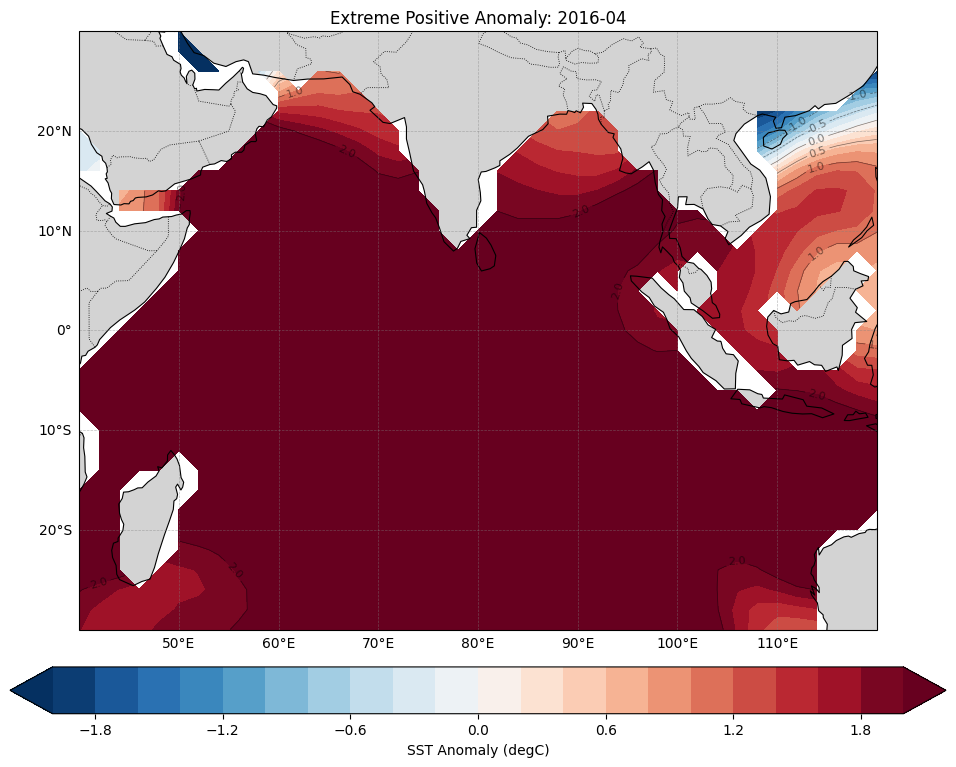

In [8]:
# ============================================================
# SECTION 7: Anomaly Detection (v2.0)
# ============================================================
# Purpose: Identify and analyze SST anomalies

if 'sst_data' in locals() and sst_data is not None and 'sst_var_name' in locals() and sst_var_name:
    # Only perform anomaly analysis if we have time dimension
    if 'time' in sst.dims and len(sst['time']) > 1:
        print("\nPerforming anomaly analysis...")

        try:
            # Calculate climatology (mean over all times)
            climatology = sst.mean(dim='time', skipna=True)

            # Calculate anomalies
            anomalies = sst - climatology

            # Plot the time series of mean anomalies
            spatial_mean_anomalies = anomalies.mean(dim=[lat_var, lon_var], skipna=True)

            # Convert to pandas Series for plotting
            anomaly_series = spatial_mean_anomalies.to_series()

            plt.figure(figsize=(12, 6))
            plt.plot(anomaly_series.index, anomaly_series.values)
            plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
            plt.title('SST Anomalies Relative to Long-term Mean')
            plt.xlabel('Time')
            plt.ylabel(f'SST Anomaly ({sst.units if hasattr(sst, "units") else "°C"})')
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            # Calculate trend in anomalies
            if len(anomaly_series) > 1:
                x = np.arange(len(anomaly_series))
                slope, intercept, r_value, p_value, std_err = stats.linregress(x, anomaly_series.values)

                # Calculate trend per decade (assuming monthly data)
                trend_per_decade = slope * 120  # 120 months in a decade

                print(f"\nAnomaly Trend Analysis:")
                print(f"  Slope: {trend_per_decade:.4f} °C/decade (p-value: {p_value:.4f})")
                print(f"  R-squared: {r_value**2:.4f}")

            # Identify extreme anomalies (> 2 standard deviations)
            std_dev = anomaly_series.std()
            extreme_pos = anomaly_series[anomaly_series > 2*std_dev]
            extreme_neg = anomaly_series[anomaly_series < -2*std_dev]

            print(f"\nExtreme Anomalies (> 2 standard deviations):")
            print(f"  Positive anomalies: {len(extreme_pos)} occurrences")
            print(f"  Negative anomalies: {len(extreme_neg)} occurrences")

            if len(extreme_pos) > 0:
                print(f"  Largest positive anomaly: {extreme_pos.max():.2f}{' ' + sst.units if hasattr(sst, 'units') else ' °C'} on {extreme_pos.idxmax()}")
            if len(extreme_neg) > 0:
                print(f"  Largest negative anomaly: {extreme_neg.min():.2f}{' ' + sst.units if hasattr(sst, 'units') else ' °C'} on {extreme_neg.idxmin()}")

            # Visual anomaly map for a specific period (most recent or extreme anomaly)
            if len(sst['time']) > 0:
                # If we have extreme anomalies, use the most extreme
                if len(extreme_pos) > 0 or len(extreme_neg) > 0:
                    if len(extreme_pos) > 0 and (len(extreme_neg) == 0 or extreme_pos.max() > abs(extreme_neg.min())):
                        extreme_date = extreme_pos.idxmax()
                        extreme_type = "positive"
                    else:
                        extreme_date = extreme_neg.idxmin()
                        extreme_type = "negative"

                    # Get the time index closest to this date
                    time_index = pd.to_datetime(sst['time'].values)
                    closest_idx = np.abs(time_index - extreme_date).argmin()
                    anomaly_map = anomalies.isel(time=closest_idx)
                    map_title = f"Extreme {extreme_type.capitalize()} Anomaly: {extreme_date.strftime('%Y-%m')}"
                else:
                    # Otherwise use the most recent
                    anomaly_map = anomalies.isel(time=-1)
                    map_title = f"Recent Anomaly: {pd.to_datetime(sst['time'].values[-1]).strftime('%Y-%m')}"

                # Create the anomaly map
                plt.figure(figsize=(12, 8))
                ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=80))

                # Add features
                ax.add_feature(cfeature.LAND, facecolor='lightgray')
                ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
                ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)

                # Plot the anomaly
                lon, lat = np.meshgrid(anomaly_map[lon_var].values, anomaly_map[lat_var].values)

                # Use a diverging colormap for anomalies
                levels = np.linspace(-2, 2, 21)  # From -2 to 2 degrees in 0.2 increments
                norm = plt.Normalize(-2, 2)

                im = ax.contourf(lon, lat, anomaly_map.values,
                               levels=levels,
                               transform=ccrs.PlateCarree(),
                               cmap='RdBu_r',  # Blue for negative, Red for positive
                               norm=norm,
                               extend='both')

                # Add contour lines
                contour = ax.contour(lon, lat, anomaly_map.values,
                                   levels=[-2, -1, -0.5, 0, 0.5, 1, 2],
                                   colors='black',
                                   linewidths=0.5,
                                   alpha=0.5,
                                   transform=ccrs.PlateCarree())
                plt.clabel(contour, inline=True, fontsize=8, fmt='%.1f')

                # Add colorbar
                cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
                cbar.set_label(f'SST Anomaly ({sst.units if hasattr(sst, "units") else "°C"})')

                # Set title
                plt.title(map_title)

                # Set extent to focus on the Indian Ocean
                ax.set_extent([40, 120, -30, 30], crs=ccrs.PlateCarree())

                # Add gridlines
                gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
                gl.top_labels = False
                gl.right_labels = False

                # Show the plot
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"Error in anomaly analysis: {e}")
    else:
        print("\nSkipping anomaly analysis: Insufficient time data")


Performing regional focus analysis...


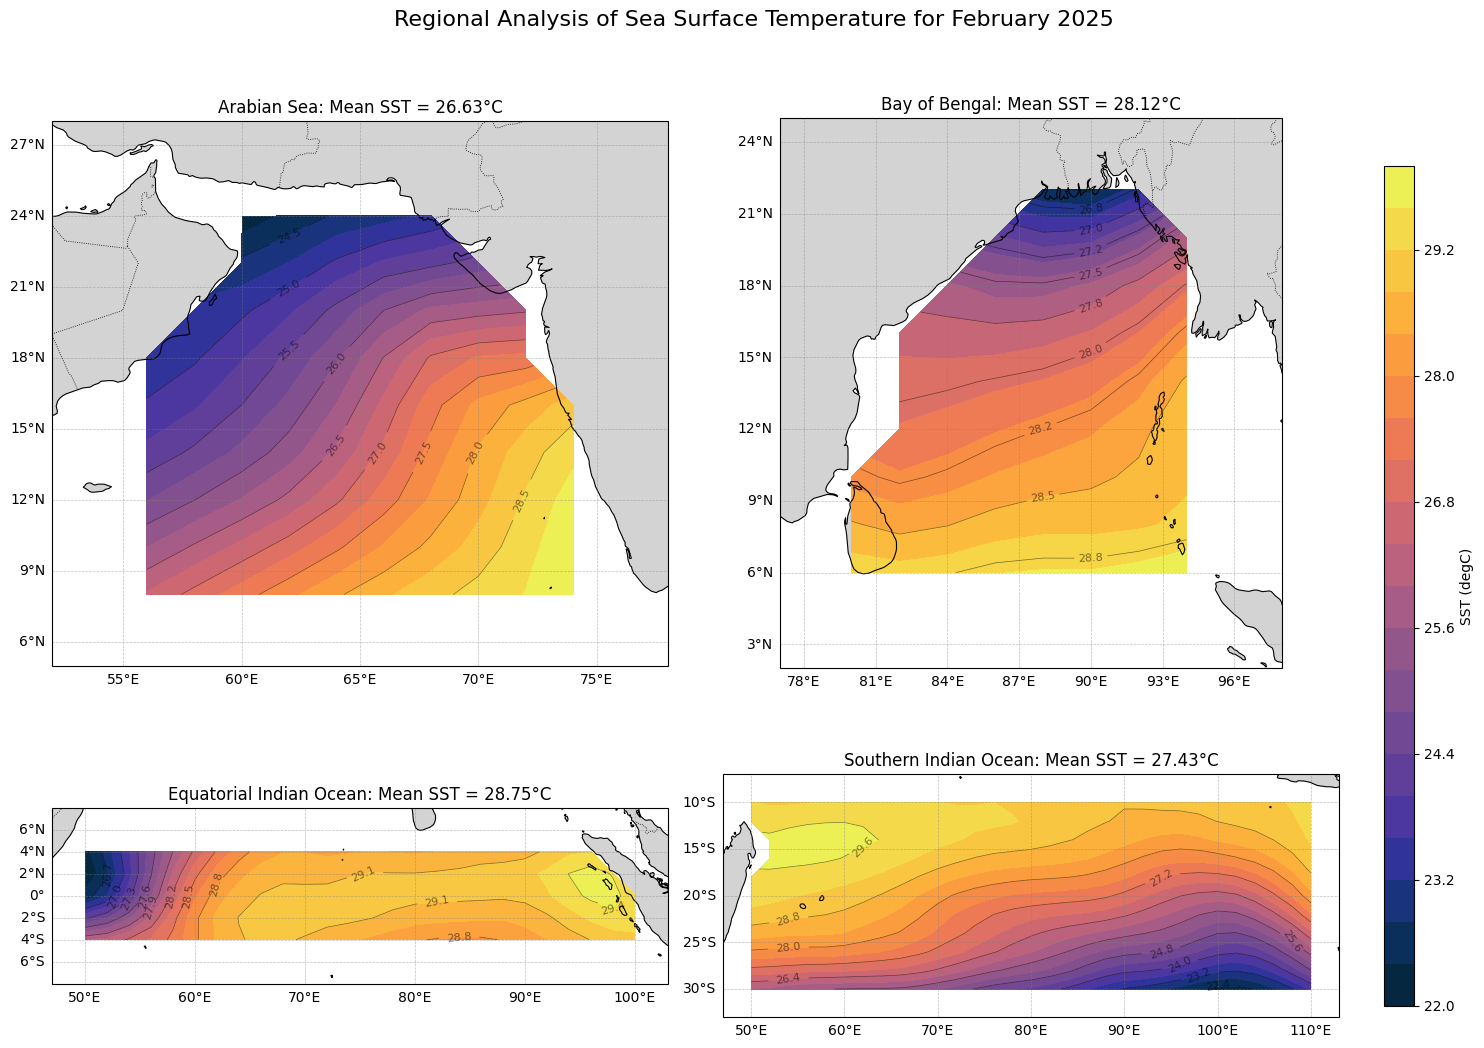


Regional Temperature Comparison:
  Equatorial Indian Ocean: 28.75°C
  Bay of Bengal: 28.12°C
  Southern Indian Ocean: 27.43°C
  Arabian Sea: 26.63°C


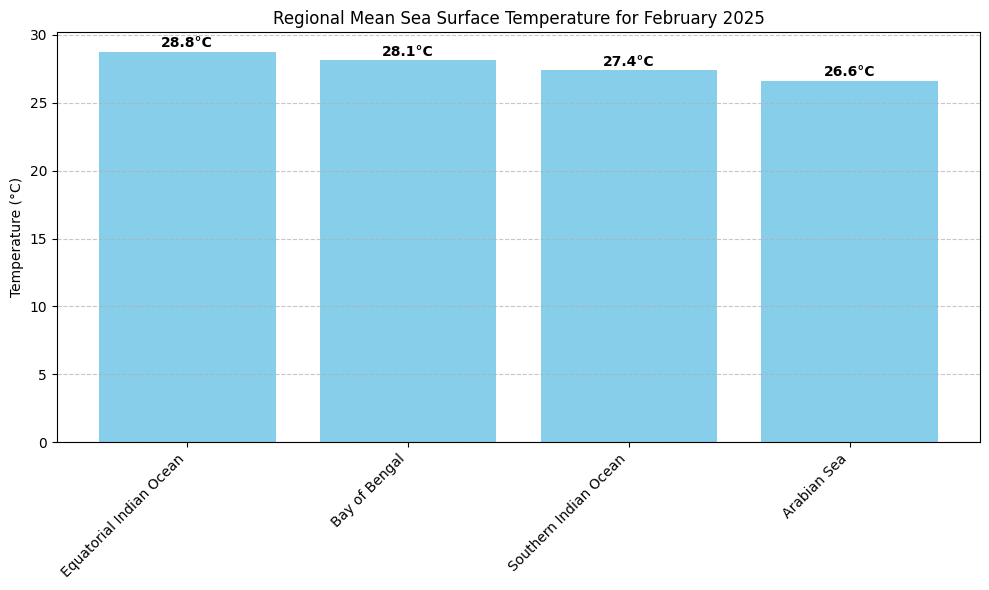

In [9]:
# ============================================================
# SECTION 8: Regional Focus Analysis (v2.0)
# ============================================================
# Purpose: Examine recent SST conditions in specific Indian Ocean sub-regions

if 'sst_data' in locals() and sst_data is not None and 'sst_var_name' in locals() and sst_var_name:
    # Define key sub-regions within the Indian Ocean
    print("\nPerforming regional focus analysis...")

    # Define sub-regions (using lat-lon bounds)
    sub_regions = {
        "Arabian Sea": {"lat": (8, 25), "lon": (55, 75)},
        "Bay of Bengal": {"lat": (5, 22), "lon": (80, 95)},
        "Equatorial Indian Ocean": {"lat": (-5, 5), "lon": (50, 100)},
        "Southern Indian Ocean": {"lat": (-30, -10), "lon": (50, 110)}
    }

    try:
        # If we have time data, use the most recent time point for regional analysis
        if 'time' in sst.dims:
            # For long time series (like ERSST), get the most recent data
            recent_sst = sst.isel(time=-1)
            recent_time = pd.to_datetime(sst_data['time'].values[-1])
            time_info = f" for {recent_time.strftime('%B %Y')}"
        else:
            # For datasets without time dimension, use the data as is
            recent_sst = sst
            time_info = ""

        # Create multi-panel plot for sub-regions
        fig, axes = plt.subplots(2, 2, figsize=(15, 12),
                               subplot_kw={'projection': ccrs.PlateCarree()})
        axes = axes.flatten()

        # Store statistics for comparison
        region_stats = {}

        # Plot each sub-region
        for i, (region_name, bounds) in enumerate(sub_regions.items()):
            if i < len(axes):
                ax = axes[i]

                # Set region-specific extent
                lat_min, lat_max = bounds["lat"]
                lon_min, lon_max = bounds["lon"]

                # Add a bit of padding around the region
                padding = 3  # degrees
                ax.set_extent([lon_min-padding, lon_max+padding,
                              lat_min-padding, lat_max+padding],
                              crs=ccrs.PlateCarree())

                # Extract sub-region data
                sub_region_indices_lat = np.where((sst_data[lat_var].values >= lat_min) &
                                                (sst_data[lat_var].values <= lat_max))[0]
                sub_region_indices_lon = np.where((sst_data[lon_var].values >= lon_min) &
                                                (sst_data[lon_var].values <= lon_max))[0]

                if len(sub_region_indices_lat) > 0 and len(sub_region_indices_lon) > 0:
                    sub_region_data = recent_sst.isel({
                        lat_var: sub_region_indices_lat,
                        lon_var: sub_region_indices_lon
                    })

                    # Calculate statistics
                    mean_temp = float(sub_region_data.mean(skipna=True).values)
                    region_stats[region_name] = mean_temp

                    # Add map features
                    ax.add_feature(cfeature.LAND, facecolor='lightgray')
                    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
                    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)

                    # Plot the data
                    lon, lat = np.meshgrid(sub_region_data[lon_var].values, sub_region_data[lat_var].values)

                    # Create contour plot
                    cs = ax.contourf(lon, lat, sub_region_data.values,
                                   transform=ccrs.PlateCarree(),
                                   cmap=cmocean.cm.thermal,
                                   levels=20)

                    # Add contour lines
                    contour = ax.contour(lon, lat, sub_region_data.values,
                                       levels=10,
                                       colors='black',
                                       linewidths=0.5,
                                       alpha=0.5,
                                       transform=ccrs.PlateCarree())
                    ax.clabel(contour, inline=True, fontsize=8, fmt='%.1f')

                    # Set title
                    ax.set_title(f'{region_name}: Mean SST = {mean_temp:.2f}°C')

                    # Add gridlines
                    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
                    gl.top_labels = False
                    gl.right_labels = False
                else:
                    ax.set_title(f"{region_name}: No data available")

        # Add a colorbar
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(cs, cax=cbar_ax)
        cbar.set_label(f'SST ({sst.units if hasattr(sst, "units") else "°C"})')

        plt.suptitle(f'Regional Analysis of Sea Surface Temperature{time_info}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 0.9, 0.95])
        plt.show()

        # Compare regions
        if region_stats:
            # Sort regions by temperature
            sorted_regions = sorted(region_stats.items(), key=lambda x: x[1], reverse=True)

            print("\nRegional Temperature Comparison:")
            for region, temp in sorted_regions:
                print(f"  {region}: {temp:.2f}°C")

            # Plot bar chart
            plt.figure(figsize=(10, 6))
            regions = [r[0] for r in sorted_regions]
            temps = [r[1] for r in sorted_regions]

            plt.bar(regions, temps, color='skyblue')
            plt.title(f'Regional Mean Sea Surface Temperature{time_info}')
            plt.ylabel('Temperature (°C)')
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)

            # Add temperature labels on bars
            for i, temp in enumerate(temps):
                plt.text(i, temp + 0.1, f'{temp:.1f}°C',
                       ha='center', va='bottom', fontweight='bold')

            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error in regional analysis: {e}")


In [10]:
# ============================================================
# SECTION 9: Data Export and Preservation (v2.0)
# ============================================================
# Purpose: Save processed data for future reference and further analysis

if 'sst_data' in locals() and sst_data is not None and 'sst_var_name' in locals() and sst_var_name:
    print("\nPreparing data export...")

    # Create a dictionary to store key results
    results = {}

    try:
        # Store time series of mean SST (if we have time data)
        if 'time' in sst.dims:
            print("Exporting time series data...")
            # Mean SST over entire region
            results['mean_sst_series'] = sst.mean(dim=[lat_var, lon_var], skipna=True).to_dataframe()

            # Monthly climatology (if we have enough data)
            if len(sst['time']) >= 12 and hasattr(sst, 'groupby'):
                print("Exporting monthly climatology...")
                results['monthly_climatology'] = sst.groupby('time.month').mean(dim='time').mean(
                    dim=[lat_var, lon_var], skipna=True).to_dataframe()

            # Anomaly time series
            if len(sst['time']) > 1:
                print("Exporting anomaly data...")
                climatology = sst.mean(dim='time', skipna=True)
                anomalies = sst - climatology
                results['anomaly_series'] = anomalies.mean(dim=[lat_var, lon_var], skipna=True).to_dataframe()

            # Regional time series
            print("Exporting regional time series...")
            for region_name, bounds in sub_regions.items():
                # Extract sub-region data
                lat_min, lat_max = bounds["lat"]
                lon_min, lon_max = bounds["lon"]

                sub_region_indices_lat = np.where((sst_data[lat_var].values >= lat_min) &
                                                (sst_data[lat_var].values <= lat_max))[0]
                sub_region_indices_lon = np.where((sst_data[lon_var].values >= lon_min) &
                                                (sst_data[lon_var].values <= lon_max))[0]

                if len(sub_region_indices_lat) > 0 and len(sub_region_indices_lon) > 0:
                    sub_region_data = sst.isel({
                        lat_var: sub_region_indices_lat,
                        lon_var: sub_region_indices_lon
                    })

                    # Calculate mean time series for this region
                    region_series = sub_region_data.mean(dim=[lat_var, lon_var], skipna=True).to_dataframe()
                    results[f'{region_name.lower().replace(" ", "_")}_series'] = region_series

        # Save to Google Drive if mounted
        try:
            # Check if Drive is mounted
            if os.path.exists('/content/drive'):
                save_dir = '/content/drive/MyDrive/SST_Analysis'

                # Create directory if it doesn't exist
                os.makedirs(save_dir, exist_ok=True)

                # Save each result to a CSV file
                for name, df in results.items():
                    output_path = os.path.join(save_dir, f'{name}.csv')
                    df.to_csv(output_path)
                    print(f"Saved {name} to {output_path}")

                print("\nData Export Complete!")
                print(f"Files saved to: {save_dir}")
            else:
                # Save locally if Drive is not mounted
                save_dir = './sst_results'
                os.makedirs(save_dir, exist_ok=True)

                for name, df in results.items():
                    output_path = os.path.join(save_dir, f'{name}.csv')
                    df.to_csv(output_path)

                print("\nData Export Complete!")
                print(f"Files saved locally to: {save_dir}")
                print("Note: To save to Google Drive, mount it first with drive.mount('/content/drive')")
        except Exception as e:
            print(f"Error saving to drive: {e}")
            print("Saving results to local Colab storage instead...")

            # Save locally
            save_dir = './sst_results'
            os.makedirs(save_dir, exist_ok=True)

            for name, df in results.items():
                output_path = os.path.join(save_dir, f'{name}.csv')
                df.to_csv(output_path)

            print(f"Files saved locally to: {save_dir}")
            print("You can download these files manually from the Colab file browser.")
    except Exception as e:
        print(f"Error in data export: {e}")


Preparing data export...
Exporting time series data...
Exporting monthly climatology...
Exporting anomaly data...
Exporting regional time series...
Saved mean_sst_series to /content/drive/MyDrive/SST_Analysis/mean_sst_series.csv
Saved monthly_climatology to /content/drive/MyDrive/SST_Analysis/monthly_climatology.csv
Saved anomaly_series to /content/drive/MyDrive/SST_Analysis/anomaly_series.csv
Saved arabian_sea_series to /content/drive/MyDrive/SST_Analysis/arabian_sea_series.csv
Saved bay_of_bengal_series to /content/drive/MyDrive/SST_Analysis/bay_of_bengal_series.csv
Saved equatorial_indian_ocean_series to /content/drive/MyDrive/SST_Analysis/equatorial_indian_ocean_series.csv
Saved southern_indian_ocean_series to /content/drive/MyDrive/SST_Analysis/southern_indian_ocean_series.csv

Data Export Complete!
Files saved to: /content/drive/MyDrive/SST_Analysis


In [11]:
# ============================================================
# SECTION 10: Summary and Next Steps
# ============================================================
# Purpose: Provide analysis summary and suggest future work

print("\n" + "="*50)
print("ANALYSIS SUMMARY")
print("="*50)
print("Indian Ocean Region SST Analysis v2.0 Complete!")

# Determine which dataset was used
if DATASET_TYPE.lower() == "ersst":
    dataset_desc = "NOAA ERSST v5 (low-resolution, long historical record)"
else:
    dataset_desc = "High-resolution SST data (recent period with detailed spatial information)"

print(f"\nDataset used: {dataset_desc}")

# Summarize key findings if available
if 'results' in locals() and results:
    print("\nKey Analyses Completed:")
    for result_name in results.keys():
        print(f"  - {result_name.replace('_', ' ').title()}")

print("\nNext Steps:")
print("1. Explore correlations with climate indices (ENSO, IOD, etc.)")
print("2. Apply similar methodology to Sea Surface Salinity (SSS) data")
print("3. Consider joint SST-SSS analysis for more comprehensive understanding")
print("4. Investigate extreme events and their oceanic/atmospheric drivers")
print("5. Examine data at different temporal scales (seasonal, annual, decadal)")

print("\nVersion History:")
print("- v1.0: Initial implementation with basic ERSST analysis")
print("- v2.0: Added modular data access with support for multiple datasets")

print("\nReferences:")
print("- ERSST Dataset: https://www.ncei.noaa.gov/products/extended-reconstructed-sst")
print("- GHRSST Data: https://podaac.jpl.nasa.gov/GHRSST")
print("- Xarray Documentation: https://docs.xarray.dev/en/stable/")
print("- Cartopy Documentation: https://scitools.org.uk/cartopy/docs/latest/")


ANALYSIS SUMMARY
Indian Ocean Region SST Analysis v2.0 Complete!

Dataset used: NOAA ERSST v5 (low-resolution, long historical record)

Key Analyses Completed:
  - Mean Sst Series
  - Monthly Climatology
  - Anomaly Series
  - Arabian Sea Series
  - Bay Of Bengal Series
  - Equatorial Indian Ocean Series
  - Southern Indian Ocean Series

Next Steps:
1. Explore correlations with climate indices (ENSO, IOD, etc.)
2. Apply similar methodology to Sea Surface Salinity (SSS) data
3. Consider joint SST-SSS analysis for more comprehensive understanding
4. Investigate extreme events and their oceanic/atmospheric drivers
5. Examine data at different temporal scales (seasonal, annual, decadal)

Version History:
- v1.0: Initial implementation with basic ERSST analysis
- v2.0: Added modular data access with support for multiple datasets

References:
- ERSST Dataset: https://www.ncei.noaa.gov/products/extended-reconstructed-sst
- GHRSST Data: https://podaac.jpl.nasa.gov/GHRSST
- Xarray Documentatio